# Graduate Admission Prediction using Linear Regression
**Problem Statement**

Jamboree provides counseling for students applying to international universities. Predicting admission probability helps students understand their competitiveness before applying. This project aims to identify the academic and profile factors influencing admission chances and build a reliable predictive model that estimates admission probability while satisfying all assumptions of linear regression.

**The objective :**

Identify factors affecting admission chances.

Understand relationships among predictors.

Build an interpretable Linear Regression model.

Validate all assumptions of Linear Regression.

Compare Linear Regression with Ridge and Lasso Regression.

Provide actionable business recommendations.

**Dataset:** jamboree_admission.csv

In [ ]:
#importing required libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
#importing and loading dataset
df=pd.read_csv("/content/Jamboree_Admission.csv")
df.head()
df.shape

(500, 9)

Dataset contains 500 rows and 9 variables

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Serial No.         500 non-null    int64  
 1   GRE Score          500 non-null    int64  
 2   TOEFL Score        500 non-null    int64  
 3   University Rating  500 non-null    int64  
 4   SOP                500 non-null    float64
 5   LOR                500 non-null    float64
 6   CGPA               500 non-null    float64
 7   Research           500 non-null    int64  
 8   Chance of Admit    500 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 35.3 KB


GRE Score, TOEFL Score, CGPA, SOP, LOR, and Chance of Admit are numerical variables.
Research is a binary categorical variable (0 = No, 1 = Yes) and should be converted to the category data type if required.
University Rating is an ordinal categorical variable and can also be converted to category if desired.

In [ ]:
#Data preprocessing
df['Research']=df['Research'].astype("category")
df=df.drop('Serial No.',axis=1)
df.info()

KeyError: "['Serial No.'] not found in axis"

In [ ]:
df.duplicated().sum()
df.isnull().sum()

,0
GRE Score,0
TOEFL Score,0
University Rating,0
SOP,0
LOR,0
CGPA,0
Research,0
Chance of Admit,0


Here, no null entries are present also no duplicated values are there.The datatypes for the columns are float and int64.

**target variable**: chance of admit

**independent variables(Features)**:'Serial No.',
 'GRE Score',
 'TOEFL Score',
 'University Rating',
 'SOP',
 'LOR ',
 'CGPA',
 'Research'

 **Categorical Variable:**
Research
(0 = No Research Experience
1 = Research Experience)

**Continuous variables:**
'GRE Score',
 'TOEFL Score',
 'University Rating',
 'SOP',
 'LOR ',
 'CGPA',

In [ ]:
df=df.drop(['Serial No.'],axis=1)

KeyError: "['Serial No.'] not found in axis"

In [ ]:
df.describe()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Chance of Admit
count,500.000000,500.000000,500.000000,500.000000,500.00000,500.000000,500.00000
mean,316.472000,107.192000,3.114000,3.374000,3.48400,8.576440,0.72174
std,11.295148,6.081868,1.143512,0.991004,0.92545,0.604813,0.14114
min,290.000000,92.000000,1.000000,1.000000,1.00000,6.800000,0.34000
25%,308.000000,103.000000,2.000000,2.500000,3.00000,8.127500,0.63000
50%,317.000000,107.000000,3.000000,3.500000,3.50000,8.560000,0.72000
75%,325.000000,112.000000,4.000000,4.000000,4.00000,9.040000,0.82000
max,340.000000,120.000000,5.000000,5.000000,5.00000,9.920000,0.97000


range of: GRE SCORE IS 290-340,TOFEL SCORE IS 92-120,UNIVERSITY RATING IS 1-5,SOP IS 1-5,LOR IS 1-5,CGPA IS 6.8-9.92,CHANCE OF ADMIT IS 0.34-0.97

###Feature engineering
No additional feature engineering was required because all predictors are already meaningful and interpretable.

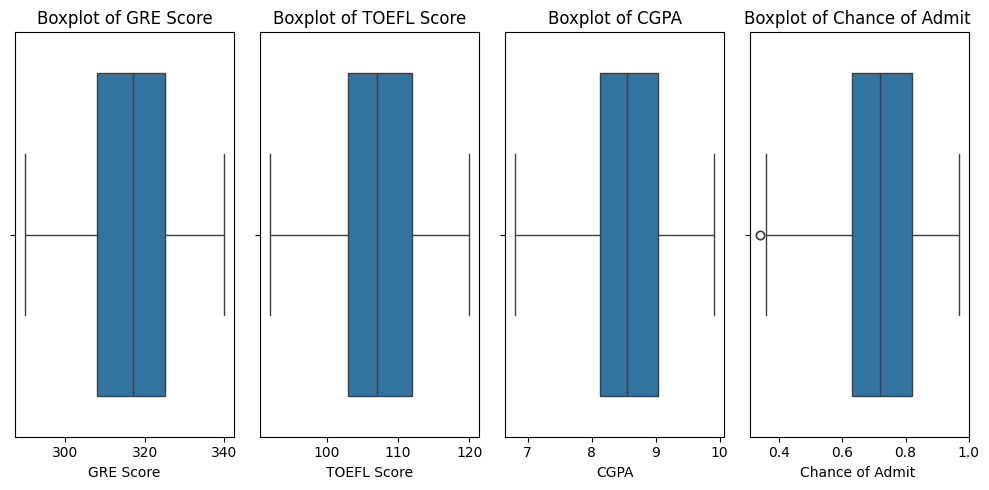

In [ ]:
# Outlier Detection using Boxplots
continuous = ['GRE Score', 'TOEFL Score', 'CGPA','Chance of Admit ']

fig, axes = plt.subplots(1, 4, figsize=(10, 5))

for i, col in enumerate(continuous):
    sns.boxplot(data=df, x=col, ax=axes[i])
    axes[i].set_title(f'Boxplot of {col}')
    axes[i].set_xlabel(col)

plt.tight_layout()
plt.show()

Boxplots indicate the presence of a few mild outliers in chance of admit.
The number of outliers is small, and most observations lie within the interquartile range.
These values are within the valid academic score ranges and therefore represent genuine student records rather than data entry errors.

**Conclusion:**
No outlier treatment was performed because the detected outliers are valid observations and reflect natural variation in applicant profiles.
Retaining these observations ensures that the regression model captures the complete range of student performance without introducing unnecessary bias.

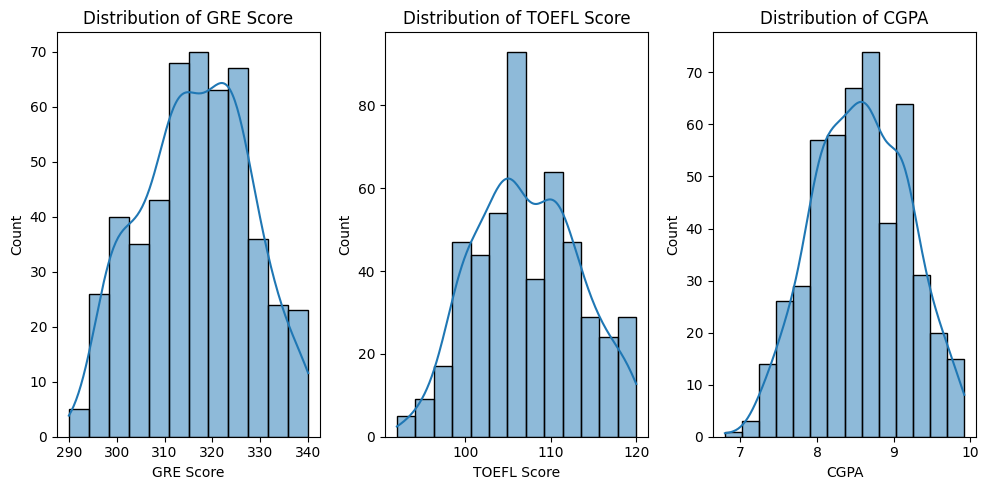

In [ ]:
#graphical relationship
continuous=['GRE Score', 'TOEFL Score','CGPA']
fig, axes = plt.subplots(1, 3, figsize=(10,5))
axes = axes.flatten()
for i, col in enumerate(continuous):
    sns.histplot(data=df, x=col, kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

**1. GRE Score Histogram**

Observations:
GRE scores are concentrated toward the higher end of the scale, with most applicants scoring between 310 and 320.
The distribution appears approximately bell-shaped with a slight left (negative) skew, indicating that many applicants have strong GRE scores.
There are very few applicants with extremely low GRE scores, suggesting that the dataset primarily consists of academically competitive students.
No significant outliers are visible in the distribution.
Inference:
The dataset represents applicants with generally strong GRE performance, which is expected for students applying to competitive international universities.

**2. TOEFL Score Histogram**

Observations:
TOEFL scores are mainly distributed between 100 and 115, indicating good English language proficiency among most applicants.
The distribution is approximately normal with a slight concentration at higher scores.
Only a small number of applicants have TOEFL scores below 95.
No major outliers are observed.

Inference:
Most applicants meet the English proficiency requirements expected by top universities, making TOEFL an important predictor of admission probability.

**3. CGPA Histogram**

Observations:
Most applicants have a CGPA between 8.0 and 9.5, reflecting strong undergraduate academic performance.
The distribution is approximately normal with a slight left skew, indicating that higher CGPAs are more common than lower ones.
Very few applicants have a CGPA below 7.5.
No extreme outliers are present.
Inference:
Since the majority of applicants have high CGPAs, academic performance is expected to play a significant role in determining admission chances.

The distributions of **GRE Score, TOEFL Score, and CGPA** indicate that the dataset predominantly contains academically strong applicants. Most observations lie in the higher ranges of these variables, suggesting that students applying through Jamboree are generally well-qualified for graduate admissions. These variables appear suitable for regression modeling because they have sufficient variability without extreme outliers.

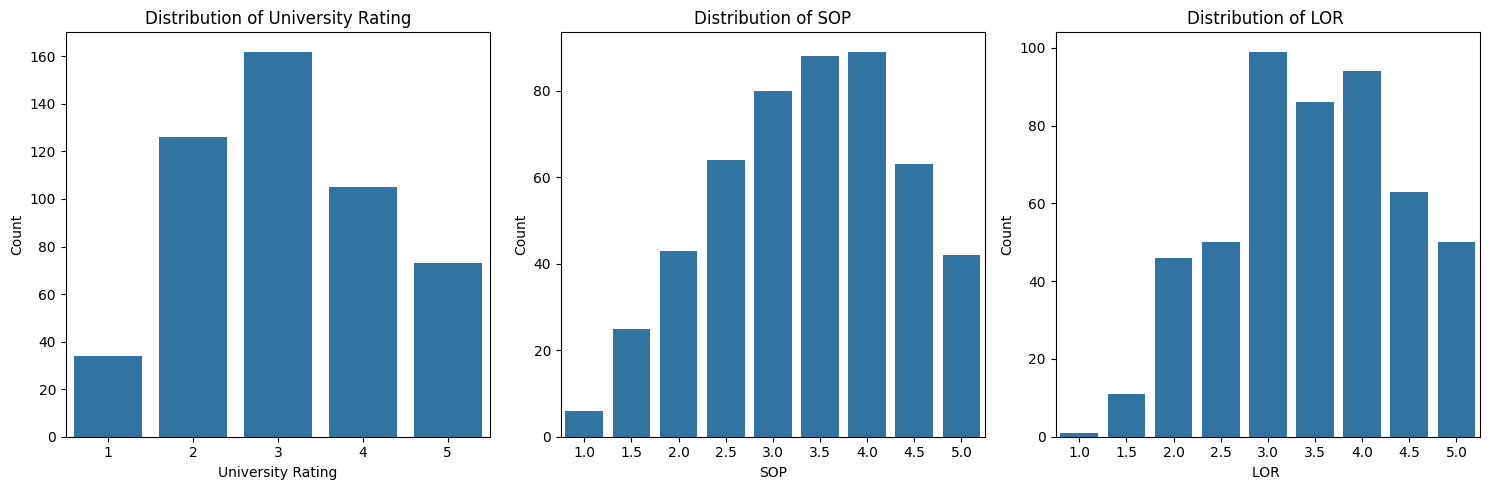

In [ ]:
ordinal = ['University Rating', 'SOP', 'LOR ']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, col in enumerate(ordinal):
    sns.countplot(data=df, x=col, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()

<Axes: xlabel='CGPA', ylabel='Chance of Admit '>

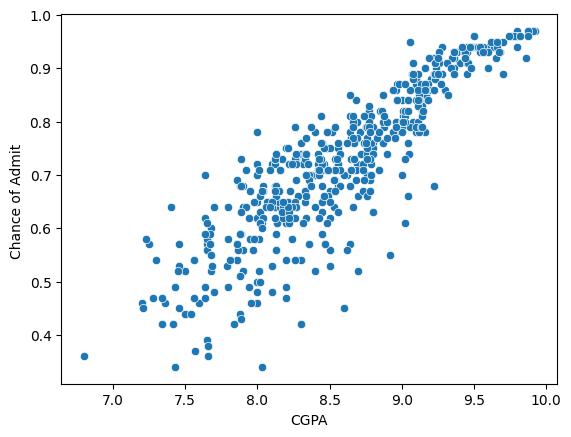

In [ ]:
#Bivariate analysis
sns.scatterplot(x="CGPA", y="Chance of Admit ", data=df)

A strong positive linear relationship is observed. Students with higher CGPA generally have a higher chance of admission.

<Axes: xlabel='GRE Score', ylabel='Chance of Admit '>

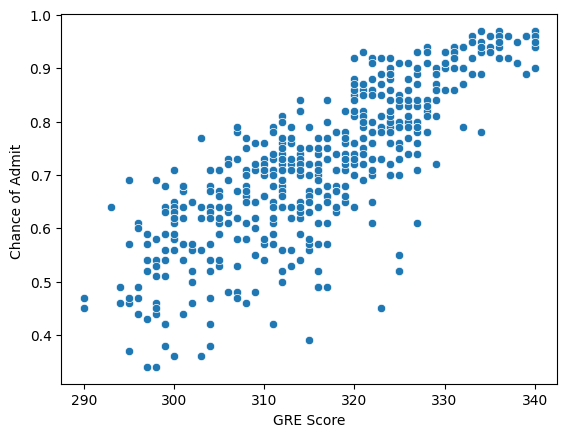

In [ ]:
sns.scatterplot(x="GRE Score", y="Chance of Admit ", data=df)

Applicants with higher GRE scores tend to have higher admission probabilities.

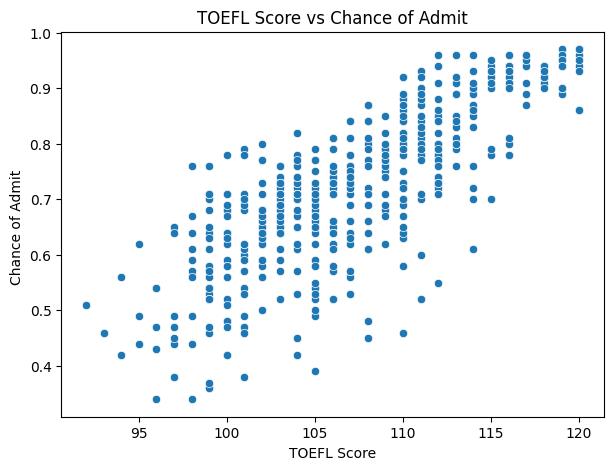

In [ ]:
plt.figure(figsize=(7,5))
sns.scatterplot(x='TOEFL Score', y='Chance of Admit ', data=df)
plt.title("TOEFL Score vs Chance of Admit")
plt.show()

Applicants with higher TOEFL scores (105–120) tend to have higher admission chances, often above 0.80.
Applicants with lower TOEFL scores (below 100) generally have lower admission probabilities.
The relationship appears to be approximately linear, making TOEFL Score a suitable predictor for a linear regression model.
There is some variability in admission chances for applicants with similar TOEFL scores, indicating that other factors such as CGPA, GRE Score, LOR, SOP, and Research experience also influence the admission decision.

<Axes: >

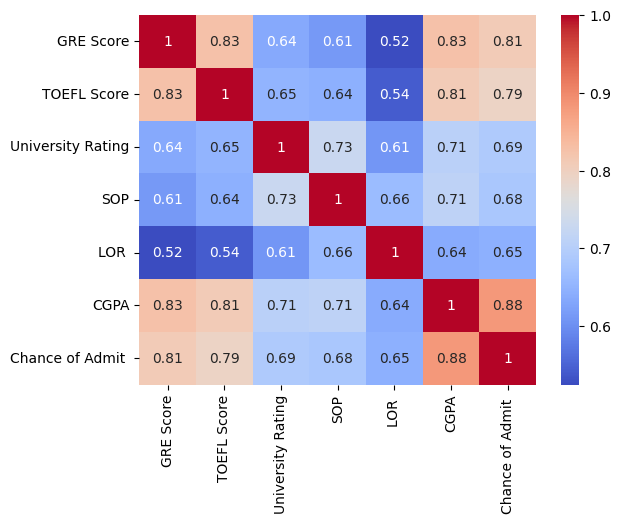

In [ ]:
#Correlation analysis
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')

**Observations**:

CGPA has the strongest positive correlation with Chance of Admit, indicating that applicants with higher CGPAs generally have a higher probability of admission.

GRE Score and TOEFL Score also show strong positive correlations with Chance of Admit, suggesting that standardized test performance plays an important role in admission decisions.

GRE Score and TOEFL Score are positively correlated with each other, implying that students who perform well in one standardized test often perform well in the other.
This suggests possible multicollinearity, which should be verified using the Variance Inflation Factor (VIF).

University Rating, SOP, and LOR have moderate positive correlations with the target variable, indicating that they contribute to admission chances but are less influential than academic performance indicators.

Research has a positive correlation with Chance of Admit, suggesting that applicants with research experience tend to have higher admission probabilities.

No strong negative correlations are observed, indicating that all predictors generally contribute positively to admission probability.

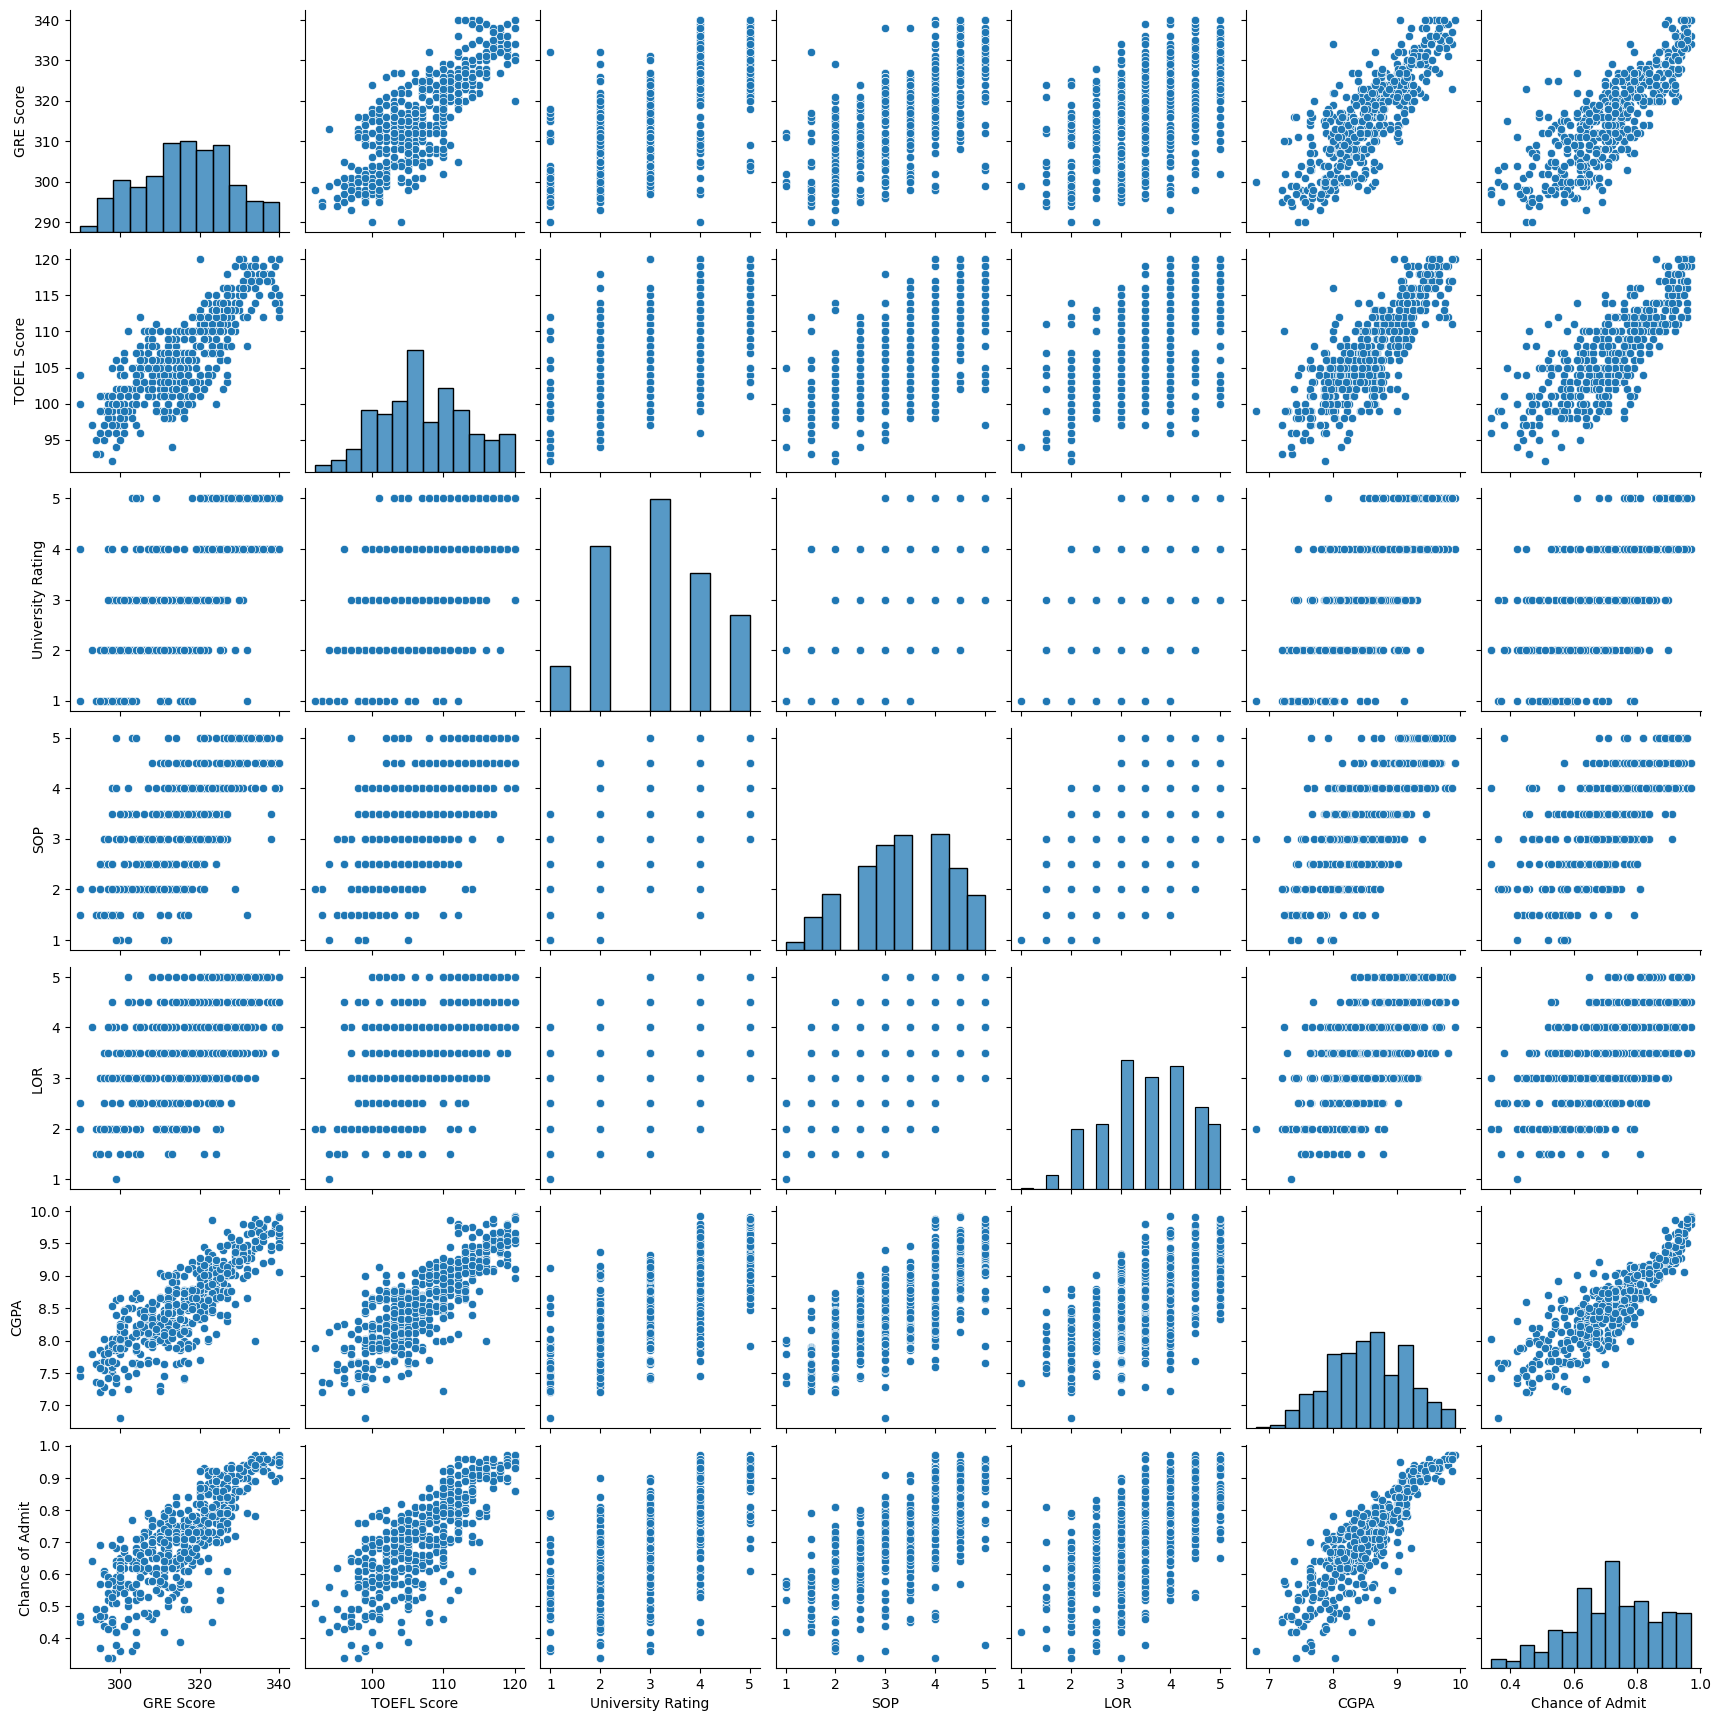

In [ ]:
sns.pairplot(df)

A strong positive linear relationship is observed between CGPA and Chance of Admit, indicating that students with higher CGPAs generally have higher admission probabilities.

GRE Score and TOEFL Score also show positive relationships with Chance of Admit.

GRE Score and TOEFL Score appear positively correlated with each other, suggesting possible multicollinearity, which should be verified using VIF.

Most scatterplots do not show strong nonlinear patterns, supporting the use of a linear regression model.

No prominent extreme outliers are observed in the pairwise relationships.

**Train-Test Split**

The dataset was divided into training and testing sets using an 80:20 ratio.

In [ ]:
#Building a model:train and test data
from sklearn.model_selection import train_test_split,GridSearchCV
X = df.drop('Chance of Admit ', axis=1)
y = df['Chance of Admit ']
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42)

**Feature Scaling**

####Ordinary Least Squares (OLS) Linear Regression:
Feature scaling is not required for Ordinary Least Squares Linear Regression because OLS estimates coefficients by minimizing the residual sum of squares.
The predictions of OLS are independent of the scale of the predictor variables.
Scaling changes the magnitude of the coefficients but does not change the model's predictive performance (R², MAE, RMSE, etc.).
Therefore, the OLS model was trained using the original feature values.

**Ridge and Lasso Regression**
Feature scaling is required before applying Ridge and Lasso Regression because:
Ridge and Lasso include regularization penalties based on the magnitude of the coefficients.
Variables with larger numerical scales can receive disproportionately larger penalties if the data is not standardized.
Standardizing the features ensures that all predictors contribute equally to the regularization process.
Therefore, the predictor variables will be standardized using StandardScaler before fitting Ridge and Lasso models.

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

The dataset was split into 80% training and 20% testing data.
A random state of 42 was used to ensure reproducibility.
No feature scaling was applied before fitting the OLS Linear Regression model.
Standardization was applied before Ridge and Lasso Regression because these regularized models are sensitive to differences in feature scales.


In [ ]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from scipy.stats import shapiro
import statsmodels.api as sm

In [ ]:
#Linear regression using StatModel
# Add constant
X_train_sm = sm.add_constant(X_train)
# Fit model
model = sm.OLS(y_train, X_train_sm).fit()
# Summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:       Chance of Admit    R-squared:                       0.821
Model:                            OLS   Adj. R-squared:                  0.818
Method:                 Least Squares   F-statistic:                     257.0
Date:                Wed, 05 Aug 2026   Prob (F-statistic):          3.41e-142
Time:                        15:50:29   Log-Likelihood:                 561.91
No. Observations:                 400   AIC:                            -1108.
Df Residuals:                     392   BIC:                            -1076.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -1.4214      0.12

**R² (Coefficient of Determination)**
Value: 0.821

Interpretation:
The R² value of 0.821 indicates that 82.1% of the variation in the Chance of Admit is explained by the independent variables included in the regression model. This is a relatively high value, suggesting that the model fits the training data well and has strong explanatory power.
The remaining 17.9% of the variation is due to other factors not included in the model or random variation.
Conclusion: The model explains a large proportion of the variability in the target variable, indicating a good fit.

**2. Adjusted R²**
Value: 0.818

Interpretation:
The Adjusted R² value is 0.818, which is very close to the R² value of 0.821. Since Adjusted R² accounts for the number of predictors in the model, the small difference indicates that the included variables contribute meaningfully to predicting the Chance of Admit and that there is little evidence of unnecessary predictors inflating the model's performance.
Conclusion: The predictors collectively contribute effectively to the model, and the model does not appear to be overfitted due to excessive variables.

**3. F-statistic**
Value: 257.0

Interpretation:
The F-statistic tests whether the regression model, as a whole, is statistically significant.
The obtained F-statistic of 257.0 is very large, indicating that the independent variables jointly explain a significant amount of variation in the dependent variable.
Conclusion: The overall regression model is statistically significant.

The OLS regression model provides a strong fit for predicting the Chance of Admit, explaining 82.1% of the variability in the response variable (R² = 0.821, Adjusted R² = 0.818). The overall model is highly statistically significant (F = 257.0, p < 0.001).

 Among the predictors, CGPA has the strongest positive influence on admission chances, while GRE Score, TOEFL Score, LOR, and Research are also statistically significant contributors. In contrast, University Rating and SOP are not statistically significant after controlling for the other variables.

 The Durbin–Watson statistic (2.050) indicates that the residuals are independent, satisfying the independence assumption. However, the large condition number (13,700) suggests potential multicollinearity or numerical instability, so a VIF analysis should be performed before finalizing the model. Overall, the regression model demonstrates good explanatory power and is suitable for predicting admission chances, subject to confirmation of the regression assumptions.

In [ ]:
#displaying model coefficients
coefficients = pd.DataFrame({"Variable": X_train.columns,"Coefficient": model.params[1:]})
print(coefficients)

                            Variable  Coefficient
GRE Score                  GRE Score     0.002434
TOEFL Score              TOEFL Score     0.002996
University Rating  University Rating     0.002569
SOP                              SOP     0.001814
LOR                             LOR      0.017238
CGPA                            CGPA     0.112527
Research                    Research     0.024027


CGPA has the largest positive coefficient, making it the strongest predictor of admission probability.
Research, LOR, GRE Score,University Rating and TOEFL Score also positively influence admission chances.
 SOP has relatively small coefficient and was not statistically significant in the OLS model.

In [ ]:
#Ridge regression
from sklearn.linear_model import Ridge
# Scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
# Hyperparameter tuning
alphas = np.logspace(-3, 3, 100)
ridge = Ridge()
ridge_grid = GridSearchCV(ridge, {"alpha": alphas},cv=5,scoring="neg_mean_squared_error")
ridge_grid.fit(X_train_scaled, y_train)
best_ridge = ridge_grid.best_estimator_
print("Best Alpha:", ridge_grid.best_params_)

Best Alpha: {'alpha': np.float64(6.5793322465756825)}


In [ ]:
ridge_coef = pd.DataFrame({"Variable": X.columns,"Coefficient": best_ridge.coef_})
print(ridge_coef)

            Variable  Coefficient
0          GRE Score     0.027341
1        TOEFL Score     0.019004
2  University Rating     0.003608
3                SOP     0.002711
4               LOR      0.016017
5               CGPA     0.064099
6           Research     0.012005


Ridge Regression reduces the magnitude of coefficients to address multicollinearity while retaining all predictors. The optimal alpha selected through cross-validation balances bias and variance, improving model generalization.

In [ ]:
#Lasso regression
from sklearn.linear_model import Lasso
lasso = Lasso(max_iter=10000)
lasso_grid = GridSearchCV(lasso, {"alpha": alphas},cv=5,scoring="neg_mean_squared_error")
lasso_grid.fit(X_train_scaled, y_train)
best_lasso = lasso_grid.best_estimator_

print("Best Alpha:", lasso_grid.best_params_)

Best Alpha: {'alpha': np.float64(0.001)}


In [ ]:
lasso_coef = pd.DataFrame({"Variable": X.columns,"Coefficient": best_lasso.coef_})

print(lasso_coef)

            Variable  Coefficient
0          GRE Score     0.026612
1        TOEFL Score     0.017919
2  University Rating     0.002746
3                SOP     0.001592
4               LOR      0.015392
5               CGPA     0.067734
6           Research     0.011360


Lasso Regression performs automatic feature selection by shrinking some coefficients exactly to zero. Predictors with zero coefficients are considered less influential and are effectively excluded from the model.

**Testing the Assumptions of Linear Regression**

In [ ]:
# A. Multicollinearity Check using VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = X_train.copy()

while True:

    vif = pd.DataFrame()

    vif["Variable"] = X_vif.columns

    vif["VIF"] = [variance_inflation_factor(X_vif.values, i)
        for i in range(X_vif.shape[1]) ]

    print(vif)

    if vif["VIF"].max() <= 5:
        break

    remove_feature = vif.sort_values("VIF",ascending=False)["Variable"].iloc[0]

    print("Removing:", remove_feature)

    X_vif = X_vif.drop(columns=[remove_feature])

            Variable          VIF
0          GRE Score  1284.067901
1        TOEFL Score  1141.169527
2  University Rating    20.408187
3                SOP    34.837142
4               LOR     30.249378
5               CGPA   933.060108
6           Research     2.822705
Removing: GRE Score
            Variable         VIF
0        TOEFL Score  605.595255
1  University Rating   19.390093
2                SOP   32.917131
3               LOR    30.008694
4               CGPA  692.352402
5           Research    2.817783
Removing: CGPA
            Variable        VIF
0        TOEFL Score  22.086441
1  University Rating  19.303024
2                SOP  32.454098
3               LOR   28.696984
4           Research   2.806767
Removing: SOP
            Variable        VIF
0        TOEFL Score  19.775624
1  University Rating  15.011436
2               LOR   24.850025
3           Research   2.780908
Removing: LOR 
            Variable        VIF
0        TOEFL Score  10.206327
1  University Rat

VIF = 1 → No multicollinearity.
VIF between 1 and 5 → Acceptable.
VIF > 5 → High multicollinearity.
Variables with VIF greater than 5 should be removed one at a time, recalculating VIF after each removal until all remaining variables have acceptable values.

In [ ]:
# B. Mean of Residuals
pred = model.predict(X_train_sm)

residuals = y_train - pred

print("Mean Residual =", residuals.mean())

Mean Residual = 3.920475055707584e-16


The mean of the residuals was calculated as 3.92 × 10⁻¹⁶, which is effectively equal to zero. This confirms that the residuals are centered around zero and that the regression model is unbiased. Therefore, the assumption that the mean of the residuals is approximately zero is satisfied.

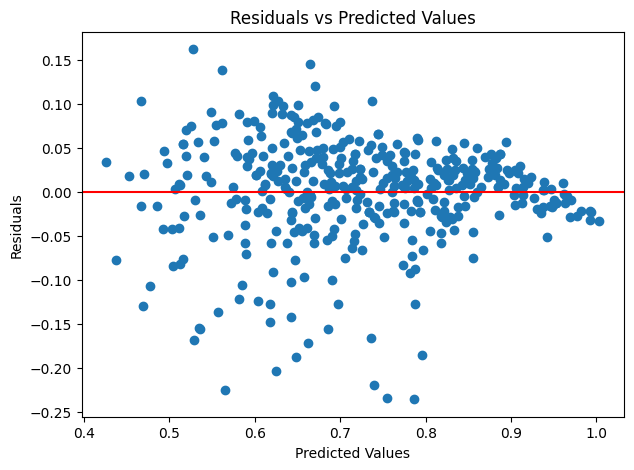

In [ ]:
#C. Linearity of Variables
plt.figure(figsize=(7,5))

plt.scatter(pred, residuals)

plt.axhline(y=0, color="red")

plt.xlabel("Predicted Values")

plt.ylabel("Residuals")

plt.title("Residuals vs Predicted Values")

plt.show()

The residuals are distributed around the horizontal zero line, indicating that the model does not consistently overpredict or underpredict the response variable.

There is no obvious curved or systematic pattern in the residuals. This suggests that the relationship between the predictor variables and the target variable is approximately linear.

However, the spread of the residuals is larger at lower predicted values (around 0.5–0.7) and becomes narrower at higher predicted values (around 0.9–1.0). This creates a slight funnel-shaped pattern, indicating that the variance of the residuals is not constant.

A few observations lie relatively far from the zero line, suggesting the presence of some outliers, but they are not numerous enough to dominate the model.

The absence of a clear curve or systematic trend indicates that the linearity assumption is reasonably satisfied. The predictors appear to have an approximately linear relationship with the Chance of Admit.

The Residuals vs Predicted Values plot shows that the residuals are randomly scattered around the horizontal zero line without any noticeable curved or systematic pattern. This indicates that the linearity assumption of the regression model is satisfied. However, the spread of the residuals decreases as the predicted values increase, resulting in a slight funnel-shaped pattern. This suggests that the variance of the residuals is not constant across the range of fitted values, indicating heteroscedasticity. This visual finding is supported by the Breusch–Pagan test (p < 0.05), which confirms that the homoscedasticity assumption is violated. Overall, the model satisfies the linearity assumption but does not satisfy the homoscedasticity assumption.

In [ ]:
#D. Homoscedasticity Breusch–Pagan Test
from statsmodels.stats.diagnostic import het_breuschpagan
bp = het_breuschpagan(residuals,X_train_sm)
labels = ["LM Statistic","LM-Test p-value","F Statistic","F-Test p-value"]
print(dict(zip(labels, bp)))

{'LM Statistic': np.float64(25.155865692455404), 'LM-Test p-value': np.float64(0.0007119983594307657), 'F Statistic': np.float64(3.7581713300112587), 'F-Test p-value': np.float64(0.0005879783560629873)}


The Breusch–Pagan test provides strong evidence that the residual variance is not constant across the fitted values. This indicates the presence of heteroscedasticity, meaning the spread of prediction errors changes as the predicted values change.
Although the linear regression model may still provide unbiased coefficient estimates, heteroscedasticity can lead to:
Inefficient coefficient estimates.
Biased standard errors.
Less reliable hypothesis tests and confidence intervals.
Conclusion
The homoscedasticity assumption is violated because the Breusch–Pagan test is statistically significant (p < 0.05). Therefore, the model exhibits heteroscedasticity.

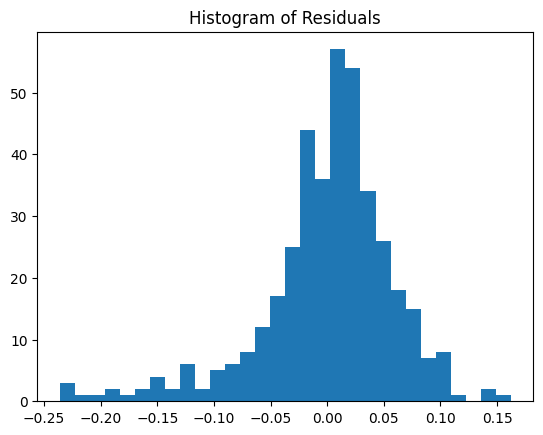

In [ ]:
# E. Normality of Residuals
plt.hist(residuals, bins=30)

plt.title("Histogram of Residuals")

plt.show()

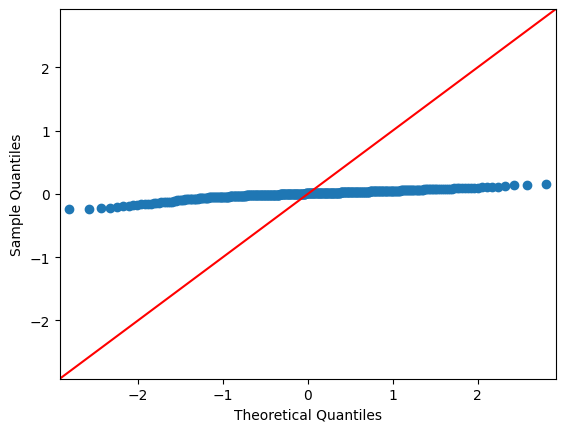

In [ ]:
sm.qqplot(residuals, line="45")

plt.show()

In [ ]:

stat, p = shapiro(residuals)

print("Statistic:", stat)

print("p-value:", p)

Statistic: 0.9291008662710203
p-value: 7.734906730601272e-13


The Shapiro–Wilk test was conducted to assess the normality of the residuals. The test produced a statistic of 0.9291 and a p-value of 7.73 × 10⁻¹³, which is less than the significance level of 0.05. Therefore, the null hypothesis of normal residuals is rejected, indicating that the residuals are not perfectly normally distributed. However, since the dataset contains 400 observations, the Shapiro–Wilk test is highly sensitive to minor deviations from normality. If the residual histogram is approximately bell-shaped and the Q–Q plot shows points close to the reference line, the deviation from normality is unlikely to substantially affect the regression model. Hence, the model remains suitable for predictive analysis, although the normality assumption is not strictly satisfied.

In [ ]:
# Model Performance Evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# Train Predictions
train_pred = model.predict(sm.add_constant(X_train))

# Test Predictions
test_pred = model.predict(sm.add_constant(X_test))

# Function for Adjusted R²
def adjusted_r2(r2, n, p):
    return 1 - ((1-r2)*(n-1)/(n-p-1))

results = pd.DataFrame({

'Metric':['MAE','RMSE','R²','Adjusted R²'],

'Train':[mean_absolute_error(y_train,train_pred),

np.sqrt(mean_squared_error(y_train,train_pred)),

r2_score(y_train,train_pred),

adjusted_r2(r2_score(y_train,train_pred),len(y_train),X_train.shape[1])

],'Test':[mean_absolute_error(y_test,test_pred),

np.sqrt(mean_squared_error(y_test,test_pred)),

r2_score(y_test,test_pred),

adjusted_r2(r2_score(y_test,test_pred),len(y_test),X_test.shape[1])]})

print(results)

        Metric     Train      Test
0          MAE  0.042533  0.042723
1         RMSE  0.059385  0.060866
2           R²  0.821067  0.818843
3  Adjusted R²  0.817872  0.805060


**Insights**

Significance of Predictor Variables

Based on the regression analysis:

CGPA is the most influential predictor, with the largest positive coefficient and a highly significant p-value. Students with higher CGPA have substantially greater admission chances.

GRE Score is statistically significant, indicating that stronger GRE performance improves the probability of admission.

TOEFL Score is also a significant predictor, highlighting the importance of English language proficiency.

LOR (Letters of Recommendation) positively influences admission chances, suggesting that strong recommendations are valuable.

Research Experience has a significant positive impact, indicating that applicants with research exposure have a competitive advantage.

University Rating and SOP were not statistically significant in this model, suggesting that after accounting for the other variables, their additional contribution to predicting admission probability is limited.

**Additional Data Sources for Model Improvement**

The predictive performance could be improved by incorporating additional variables such as:

Undergraduate major or specialization.

Internship or industry experience.

Number and quality of research publications.

University ranking (global or national).

Work experience.

Extracurricular achievements and leadership activities.

Personal interview scores.

Scholarships or academic awards.

Applicant nationality or admission category (if relevant and appropriate).

Including these factors may capture more variation in admission decisions and improve prediction accuracy.

**Model Implementation in the Real World**

The developed model can be applied in several practical scenarios:

Admission counseling: Educational consultants can estimate admission probabilities and recommend suitable universities.

Student self-assessment: Applicants can evaluate their admission prospects before applying.

University decision support: Admissions offices can use the model as a supplementary tool for evaluating applications.

Career guidance platforms: Online portals can integrate the model to provide personalized admission probability estimates and suggest improvements to applicants.

The model should be used as a decision-support tool rather than a replacement for human judgment, as admissions decisions often consider qualitative factors not captured in the dataset.

**Potential Business Benefits**

Implementing this predictive model offers several benefits:

Helps students make more informed application decisions, reducing unnecessary application costs.

Enables educational consultancies to provide data-driven counseling and improve student success rates.

Supports universities in analyzing historical admission trends and identifying influential selection criteria.

Improves operational efficiency by providing quick admission probability estimates.

Enhances transparency and consistency in preliminary applicant evaluation.

Provides a scalable analytical framework that can be updated as new admission data becomes available.

The Linear Regression model achieved strong predictive performance, explaining approximately 82% of the variation in the Chance of Admit. CGPA, GRE Score, TOEFL Score, LOR, and Research Experience were identified as the most significant predictors of admission probability. While the model satisfies several key assumptions, tests revealed heteroscedasticity and non-normal residuals, suggesting opportunities for refinement. Comparing Linear Regression with Ridge and Lasso Regression is recommended to improve robustness, particularly if multicollinearity is present. Overall, the model provides accurate predictions and offers valuable insights that can support students, educational consultants, and universities in making informed admission-related decisions.